In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [60]:
api = wandb.Api()

In [56]:
EXPERIMENT_GROUP = {
    "single":   "./artifacts/2023-10-s16/distill-layerwise/run2/investiate-role-spurious-corr-single-location",
    "singlex20y20":   "./artifacts/2023-10-s16/distill-layerwise/run2/investiate-role-spurious-corr-single-location-x20y20",
    "multiple": "./artifacts/2023-10-s16/distill-layerwise/run2/investiate-role-spurious-corr",
    "multiple-cleands": "./artifacts/2023-10-s16/distill-layerwise/run2/investiate-role-spurious-corr-multiple-locations-clean-ds-for-bases",
}

In [57]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    spurious_mode,
    arr_training_sizes,
    arr_contamination_levels,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP[spurious_mode]},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": {"$in": arr_training_sizes}},
            {"config.contamination_level": {"$in": arr_contamination_levels}},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    commit = None
    for run in runs:
        if commit == None:
            commit = run.description.split("\n")[-1].strip()
        else:
            assert commit == run.description.split("\n")[-1].strip()
            
        seed = run.config["seed"]
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["training_size", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        3,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    spurious_mode="single",
    policy="basis-identity:pca--uncentered",
    arr_training_sizes=[1.0],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    lambda_task=0.0,
    lambda_kd=1.0,
    verbose=True,
)

summary

we have 12 runs
df.shape: (4, 12)


training_size contamination_level   val_acc                 val_agreement  \
                                         mean       std count          mean   
0             1                0.00  0.600000  0.015100     3      0.630667   
1             1                0.25  0.588667  0.013013     3      0.608667   
2             1                0.50  0.598667  0.011015     3      0.628667   
3             1                0.75  0.550667  0.020526     3      0.589333   

                  val_agreement_on_teacher_correct                 teacher_acc  
        std count                             mean       std count        mean  
0  0.006429     3                         0.474000  0.009165     3    0.620000  
1  0.014742     3                         0.462000  0.005291     3    0.623333  
2  0.012220     3                         0.476000  0.010583     3    0.623333  
3  0.019009     3                         0.438667  0.012858     3    0.621333

In [61]:
read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    spurious_mode="multiple-cleands",
    policy="basis-identity:pca--uncentered",
    arr_training_sizes=[1.0],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    lambda_task=0.0,
    lambda_kd=1.0,
    verbose=True,
)


we have 12 runs
df.shape: (4, 12)


training_size contamination_level   val_acc                 val_agreement  \
                                         mean       std count          mean   
0             1                0.00  0.613333  0.008327     3      0.626667   
1             1                0.25  0.582667  0.011719     3      0.592667   
2             1                0.50  0.514667  0.016653     3      0.550000   
3             1                0.75  0.412000  0.026458     3      0.481333   

                  val_agreement_on_teacher_correct                 teacher_acc  
        std count                             mean       std count        mean  
0  0.012220     3                         0.480000  0.007211     3    0.620000  
1  0.006429     3                         0.450667  0.007024     3    0.614667  
2  0.024980     3                         0.403333  0.016166     3    0.607333  
3  0.007024     3                         0.331333  0.010263     3    0.604667

# Comparison on `training-size` and `contamination-level`

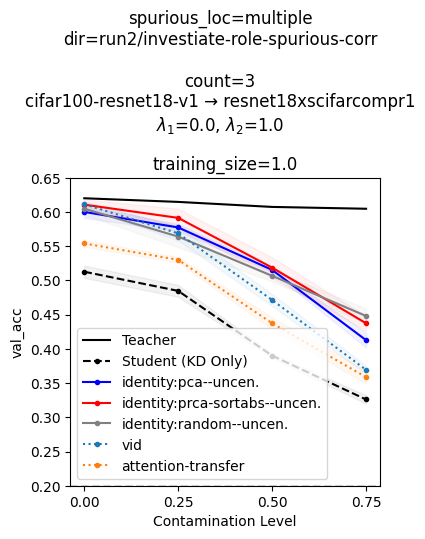

In [26]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "nothing":
        return "--"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    if "basis" in policy:
    
        return policy \
            .replace("basis-identity", "identity") \
            .replace("uncentered", "uncen.")
    
    elif policy == "nothing":
        return "Student (KD Only)"
    
    else:
        return policy

    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif policy == "nothing":
        return "black"
    elif "random" in policy:
        return "gray"
    elif policy == "fitnetinvidinner" or policy == "fitnetinvidbnrelu":
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher, student, policies, 
    arr_training_sizes,
    arr_contamination_levels,
    spurious_mode,
    show_legend=True,
):
        
    lambda_kd = 1.0
    lambda_task = 0.0


    col = "val_acc"
    
    ncols = len(arr_training_sizes)
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP[spurious_mode]}".split("/")[-2:])
    
    for tix, training_size in enumerate(arr_training_sizes):
        plt.subplot(nrows, ncols, tix+1)
        plt.title(f"training_size={training_size}")
        
        for pix, policy in enumerate(policies):
            df = read_data(
                teacher=teacher,
                student=student,
                policy=policy,
                
                spurious_mode=spurious_mode,
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,

                arr_training_sizes=[training_size],
                arr_contamination_levels=arr_contamination_levels,
                verbose=False
            )
            
            ticks = df["contamination_level"]

            
            # visualize baseline
            if pix == 0:

                plt.plot(
                    ticks,
                    df["teacher_acc"],
                    ls="-",
                    color="k",
                    label="Teacher"
                )
                

                plt.ylim(bottom=0.2, top=0.65)
                plt.axhline(0.2, ls="--", color="lightgray")

            # here, we take the first value.
            # the query function already checks that the value is expected
            count = df[col]["count"].values[-1]

            mean = df[col]["mean"]
            stderr = df[col]["std"] / (count ** 0.5)

            plt.plot(
                ticks,
                mean,
                marker=".",
                label=alias(policy),
                ls=ls(policy),
                color=color(policy)
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.05,
                color=plt.gca().lines[-1].get_color()
            )

        plt.xlabel("Contamination Level")
        plt.xticks(ticks)
        if tix==0:
            plt.ylabel(col)

            plt.legend()

    plt.suptitle(
        "\n".join([
            f"spurious_loc={spurious_mode}",
            f"dir={dirslug}",
            "",
            f"count={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
        ]),
        y=1.3,
    )

viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    spurious_mode="multiple",
    arr_training_sizes=[1.0],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    policies = [ 
        "nothing",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
    ],
) 

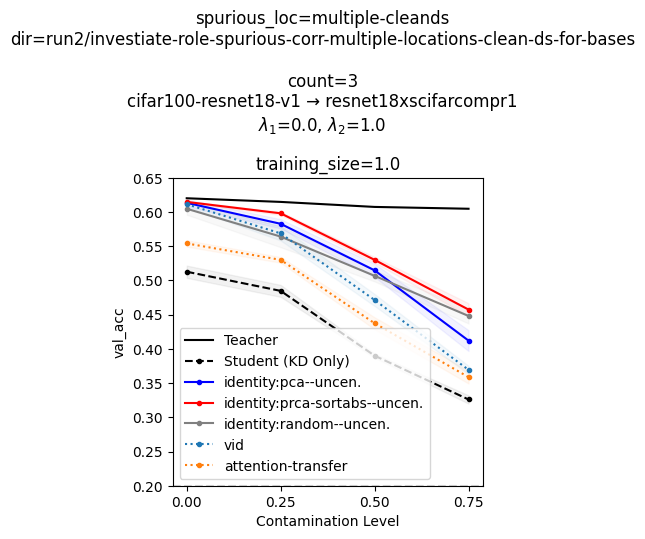

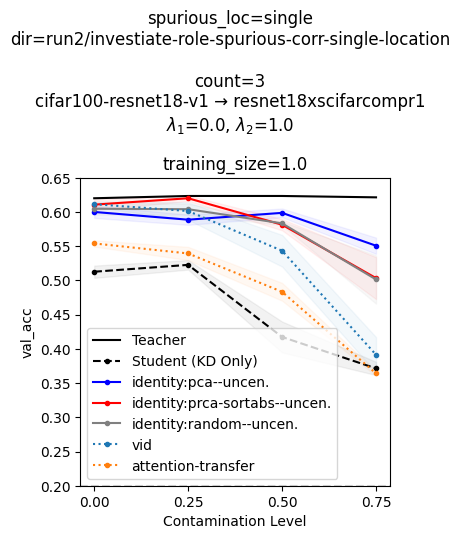

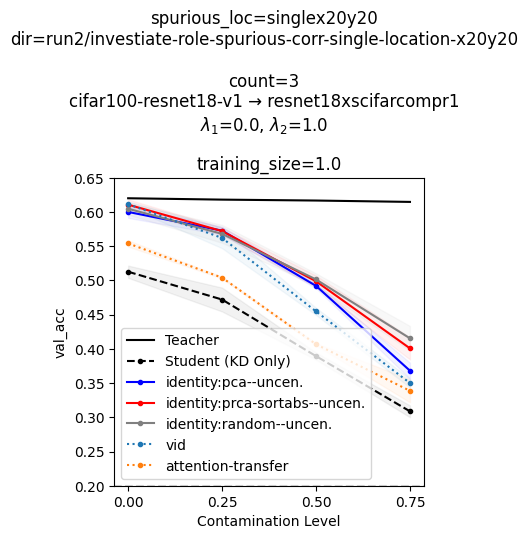

In [62]:
for mode in ["multiple-cleands", "single", "singlex20y20"]:
    viz_distillation(
        teacher = "cifar100-resnet18-v1",
        student="resnet18xscifarcompr1",
        spurious_mode=mode,
        arr_training_sizes=[1.0],
        arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
        policies = [ 
            "nothing",
            "basis-identity:pca--uncentered",
            "basis-identity:prca-sortabs--uncentered",
            "basis-identity:random--uncentered",
            "vid",
            "attention-transfer",
        ],
    ) 

# Summary (to be written)

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3$ is set according to the hyperparameter optimization with `contamination-level=0.5` and `training-size=1.0`.

*Aims:* 
- investigate the benefit of using PRCA when varying these aspects:
    - the quality of data
    - the quantity of data

    - the size of the student model

*Conclusions:*
- So, it seems that `attention-transfer` is still better than `pca` and `prca` when contamination level is 0.75. For other values, `pca` seems to be the  bes


*Further Refinement*: 
- Currently, the $\lambda_3$ is tuned for singla location. We might have to take into account its effect here.